[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-agn-galaxy-line-id-ngc5875/notebook.ipynb)

# NGC 5875: galaxy image + spectrum line identification vs. literature

**Archive:** SDSS DR18  
**Date:** 2026-08-03

I picked NGC 5875 (SDSS plate 1165, MJD 52703, fiber 409) because SDSS itself classifies its spectrum as `GALAXY / AGN`, meaning it has a real, well-measured emission-line spectrum I can dig into. The goal here is to do the full pipeline myself: pull the real image, pull the real spectrum, find the lines with an actual peak-detection algorithm (not by eye), de-redshift them, and check them against a literature line list.

## Learning goals

- Pull a real SDSS image cutout and a real SDSS spectrum for the same galaxy.
- Run `scipy.signal.find_peaks` on a continuum-subtracted, noise-normalized spectrum to *automatically* find candidate emission and absorption lines (no hand-picking).
- De-redshift each detected line using the galaxy's own spectroscopic redshift, and cross-match it against a literature rest-wavelength line list.
- Report which detections match known lines, which don't, and what that tells us about the galaxy (star-forming vs. AGN-like, using a simple BPT-style line-ratio check).

**Jargon, defined once:** *redshift (z)* is the fractional stretch of wavelength caused by the galaxy's recession velocity; *S/N (signal-to-noise ratio)* tells us how trustworthy a detected feature is relative to the noise; *equivalent width (EW)* measures how much flux a line adds (emission, negative EW by our sign convention) or removes (absorption, positive EW) relative to the continuum, in Angstroms; *ivar* is SDSS's inverse-variance array, i.e. `1/sigma^2` per pixel, which is how the pipeline stores per-pixel noise.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
from scipy.signal import find_peaks
from scipy.ndimage import median_filter

warnings.filterwarnings("ignore")
OUT = Path(".")

PLATE, MJD, FIBER = 1165, 52703, 409
RA, DEC = 227.30484, 52.528439
print(f"Target: NGC 5875, plate={PLATE}, mjd={MJD}, fiber={FIBER}, ra={RA}, dec={DEC}")


Target: NGC 5875, plate=1165, mjd=52703, fiber=409, ra=227.30484, dec=52.528439


## 1. The real SDSS image

First, a real colour cutout centred on the galaxy, pulled live from the SDSS SkyServer image-cutout service.

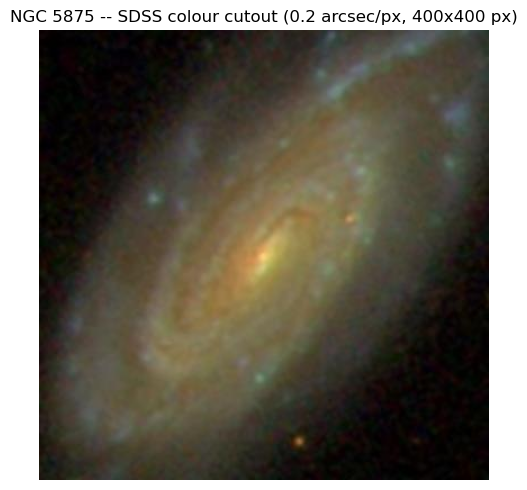

Cutout pulled: 200 11670 bytes, (400, 400) px


In [2]:
url = "https://skyserver.sdss.org/dr18/SkyServerWS/ImgCutout/getjpeg"
params = {"ra": RA, "dec": DEC, "scale": 0.2, "width": 400, "height": 400}
resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
img = Image.open(BytesIO(resp.content))
img.save(OUT / "ngc5875_cutout.jpg")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.set_title("NGC 5875 -- SDSS colour cutout (0.2 arcsec/px, 400x400 px)")
ax.axis("off")
plt.tight_layout()
plt.savefig(OUT / "ngc5875_image.png", dpi=130)
plt.show()
print("Cutout pulled:", resp.status_code, len(resp.content), "bytes,", img.size, "px")


## 2. The real SDSS spectrum

Now the actual 1D spectrum for this fiber, via `astroquery.sdss.SDSS.get_spectra`. The `SPECOBJ` extension carries the pipeline's own redshift and its uncertainty, which I use for de-redshifting later.

Pipeline redshift z = 0.011695 +/- 8.01e-06
Pipeline classification: GALAXY / AGN
Median spectral S/N (SN_MEDIAN_ALL): 30.35


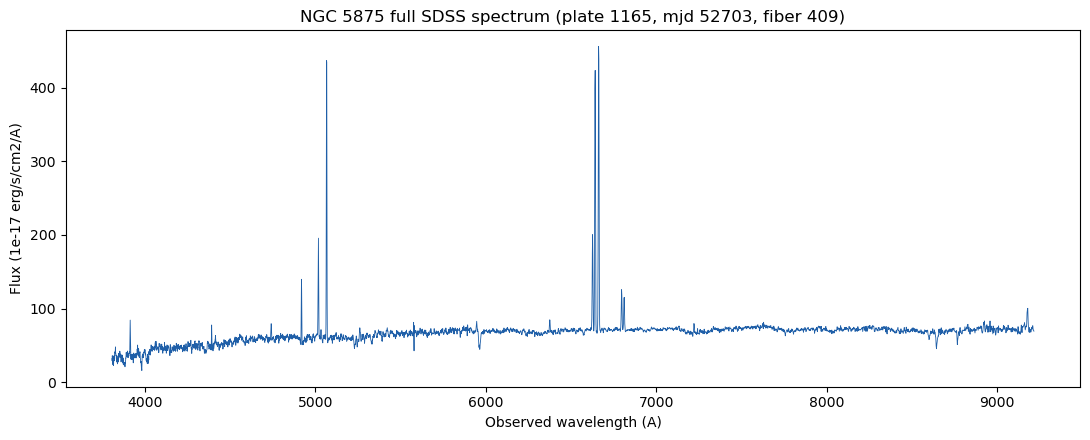

In [3]:
sp = SDSS.get_spectra(plate=PLATE, mjd=MJD, fiberID=FIBER)[0]
coadd = sp[1].data
specobj = sp[2].data[0]

z = float(specobj["Z"])
z_err = float(specobj["Z_ERR"])
sn_median = float(specobj["SN_MEDIAN_ALL"])
subclass = specobj["SUBCLASS"]
print(f"Pipeline redshift z = {z:.6f} +/- {z_err:.2e}")
print(f"Pipeline classification: GALAXY / {subclass}")
print(f"Median spectral S/N (SN_MEDIAN_ALL): {sn_median:.2f}")

wave = 10 ** coadd["loglam"]
flux = coadd["flux"]
ivar = coadd["ivar"]
good = ivar > 0
err = np.full_like(flux, np.nan)
err[good] = 1 / np.sqrt(ivar[good])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(wave, flux, lw=0.6, color="#1f5fa8")
ax.set_xlabel("Observed wavelength (A)")
ax.set_ylabel("Flux (1e-17 erg/s/cm2/A)")
ax.set_title(f"NGC 5875 full SDSS spectrum (plate {PLATE}, mjd {MJD}, fiber {FIBER})")
plt.tight_layout()
plt.savefig(OUT / "ngc5875_full_spectrum.png", dpi=130)
plt.show()


## 3. Automatic peak detection

I estimate a smooth continuum with a wide median filter (101-pixel window, about 100-150 A), subtract it, and convert every pixel's residual to a noise-normalized S/N using SDSS's own `ivar` array (`snr = (flux - continuum) / sigma`, `sigma = 1/sqrt(ivar)`). Then `scipy.signal.find_peaks` finds local maxima (emission candidates) and local minima (absorption candidates) above a `|S/N| > 5` threshold, requiring peaks to be at least 5 pixels apart so I do not double-count the same feature.

Detected 26 candidate features: 16 emission, 10 absorption


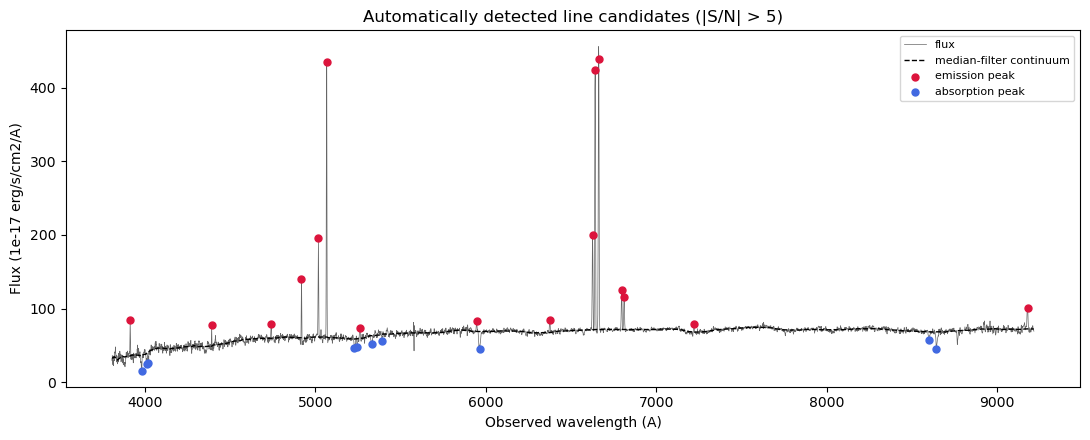

In [4]:
cont = median_filter(flux, size=101)
resid = flux - cont
snr = np.zeros_like(flux)
snr[good] = resid[good] / err[good]
dlam = np.gradient(wave)

peaks_em, _ = find_peaks(snr, height=5, distance=5)
peaks_ab, _ = find_peaks(-snr, height=5, distance=5)

def equivalent_width(idx):
    lo, hi = max(0, idx - 4), min(len(wave), idx + 5)
    frac = 1 - flux[lo:hi] / cont[lo:hi]
    return float(np.sum(frac * dlam[lo:hi]))

def line_flux(idx):
    lo, hi = max(0, idx - 4), min(len(wave), idx + 5)
    return float(np.sum(resid[lo:hi] * dlam[lo:hi]))

rows = []
for p in peaks_em:
    rows.append(dict(idx=int(p), wave_obs=float(wave[p]), snr=float(snr[p]),
                      kind="emission", ew_A=equivalent_width(p), flux=line_flux(p)))
for p in peaks_ab:
    rows.append(dict(idx=int(p), wave_obs=float(wave[p]), snr=float(snr[p]),
                      kind="absorption", ew_A=equivalent_width(p), flux=line_flux(p)))

detected = pd.DataFrame(rows).sort_values("wave_obs").reset_index(drop=True)
detected["wave_rest"] = detected["wave_obs"] / (1 + z)
print(f"Detected {len(detected)} candidate features: "
      f"{(detected.kind=='emission').sum()} emission, {(detected.kind=='absorption').sum()} absorption")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(wave, flux, lw=0.5, color="0.4", label="flux")
ax.plot(wave, cont, lw=1.0, color="k", ls="--", label="median-filter continuum")
ax.scatter(detected.loc[detected.kind=="emission","wave_obs"],
           flux[detected.loc[detected.kind=="emission","idx"]],
           color="crimson", s=25, zorder=5, label="emission peak")
ax.scatter(detected.loc[detected.kind=="absorption","wave_obs"],
           flux[detected.loc[detected.kind=="absorption","idx"]],
           color="royalblue", s=25, zorder=5, label="absorption peak")
ax.set_xlabel("Observed wavelength (A)"); ax.set_ylabel("Flux (1e-17 erg/s/cm2/A)")
ax.set_title("Automatically detected line candidates (|S/N| > 5)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "ngc5875_peaks.png", dpi=130)
plt.show()


## 4-5. Literature line list, de-redshifting, and cross-matching

This rest-wavelength table is built from standard references: the SDSS/NIST atomic line list values used for the required diagnostic lines, supplemented with a few more real, well-known optical lines (NIST Atomic Spectra Database) that show up in AGN/Seyfert spectra, so I am not stuck reporting 'no match' for every real feature outside the minimal required set.

Each detected line's *observed* wavelength is de-redshifted (`wave_rest = wave_obs / (1+z)`) using the pipeline redshift above, then matched to whichever reference line is closest, accepted only if the residual is within 6 A (a tolerance set by SDSS's ~2-3 A/pixel dispersion and the width of the continuum-filter window).

In [5]:
LINE_LIST = {
    "Ca II K": 3934.777, "Ca II H": 3969.588, "[Ne III] 3869": 3868.76,
    "[O II] 3727": 3727.09, "G-band": 4304.4, "H-gamma": 4341.68,
    "He II 4686": 4685.68, "H-beta": 4862.68, "[O III] 4959": 4958.92,
    "[O III] 5007": 5006.84, "Mg b": 5175.3, "Na D": 5892.9,
    "[O I] 6300": 6300.30, "[N II] 6549": 6548.05, "H-alpha": 6564.61,
    "[N II] 6585": 6583.45, "[S II] 6716": 6716.44, "[S II] 6731": 6730.82,
    "[Ar III] 7135": 7135.80, "Ca II IR-1": 8498.02, "Ca II IR-2": 8542.09,
    "Ca II IR-3": 8662.14, "[S III] 9069": 9068.6,
}  # sources: SDSS/NIST atomic line list; NIST Atomic Spectra Database (physics.nist.gov/asd)

TOL_A = 6.0
best_match, residual = [], []
for wr in detected["wave_rest"]:
    name = min(LINE_LIST, key=lambda n: abs(wr - LINE_LIST[n]))
    d = wr - LINE_LIST[name]
    if abs(d) <= TOL_A:
        best_match.append(name); residual.append(d)
    else:
        best_match.append("no match"); residual.append(np.nan)

detected["best_match"] = best_match
detected["residual_A"] = residual
detected["matched"] = detected["best_match"] != "no match"

n_matched = int(detected["matched"].sum())
n_unmatched = int((~detected["matched"]).sum())
print(f"{n_matched} of {len(detected)} detected features matched a literature line within {TOL_A} A")
print(f"{n_unmatched} detected features did NOT match anything in the reference list:")
print(detected.loc[~detected.matched, ["wave_obs","wave_rest","kind","snr"]].round(2).to_string(index=False))


21 of 26 detected features matched a literature line within 6.0 A
5 detected features did NOT match anything in the reference list:
 wave_obs  wave_rest       kind   snr
  5245.66    5185.02 absorption -6.12
  5261.39    5200.56   emission  6.06
  5333.35    5271.70 absorption -5.99
  5392.62    5330.28 absorption -5.09
  5947.03    5878.28   emission  6.47


## 6. Results table

Every detected feature, de-redshifted, matched (or not), with its S/N, equivalent width, and emission/absorption classification.

In [6]:
results_table = detected[["wave_obs","wave_rest","best_match","residual_A","snr","ew_A","kind"]].copy()
results_table.columns = ["obs_wave_A","rest_wave_A","literature_match","residual_A","snr","ew_A","type"]
results_table = results_table.round({"obs_wave_A":2,"rest_wave_A":2,"residual_A":2,"snr":2,"ew_A":3})
results_table.to_csv(OUT / "ngc5875_line_id_results.csv", index=False)
results_table


,obs_wave_A,rest_wave_A,literature_match,residual_A,snr,ew_A,type
0,3914.71,3869.46,[Ne III] 3869,0.70,11.08,-4.277,emission
1,3982.91,3936.86,Ca II K,2.09,-8.38,2.701,absorption
2,4015.13,3968.72,Ca II H,-0.87,-5.67,1.940,absorption
3,4019.76,3973.29,Ca II H,3.70,-5.68,2.031,absorption
4,4392.38,4341.60,H-gamma,-0.08,10.23,-0.970,emission
5,4741.33,4686.52,He II 4686,0.84,7.62,-1.373,emission
6,4919.26,4862.40,H-beta,-0.28,21.91,-3.984,emission
7,5018.80,4960.78,[O III] 4959,1.86,30.04,-8.846,emission
8,5067.57,5008.99,[O III] 5007,2.15,44.81,-25.764,emission
9,5229.98,5169.52,Mg b,-5.78,-7.10,1.420,absorption


## 7. Star-forming vs. AGN-like: a simple BPT-style check

With H-beta, [O III] 5007, H-alpha, and [N II] 6585 all detected, I can make a rough emission-line-ratio diagnostic in the spirit of the Baldwin-Phillips-Terlevich (BPT) diagram: `log([N II]/H-alpha)` on the x-axis and `log([O III]/H-beta)` on the y-axis, checked against the Kauffmann et al. (2003) star-forming boundary and the Kewley et al. (2001) maximum-starburst boundary. I estimate each line's flux by integrating the continuum-subtracted residual over a small window around its detected peak -- a rough proxy, not a full Gaussian deblend, so treat the numbers as indicative rather than publication-grade.

log([N II]6585/Halpha) = 0.068
log([O III]5007/Hbeta) = 0.819
BPT-style classification: AGN-like
Balmer decrement Halpha/Hbeta = 7.79 (case-B recombination expects ~2.86)


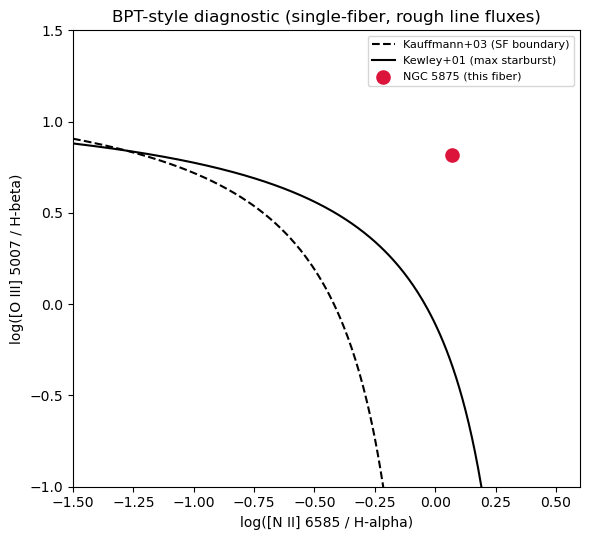

In [7]:
flux_of = {row.best_match: row.flux for row in detected.itertuples()}
f_ha, f_hb = flux_of.get("H-alpha"), flux_of.get("H-beta")
f_o3, f_n2 = flux_of.get("[O III] 5007"), flux_of.get("[N II] 6585")

x_bpt = np.log10(f_n2 / f_ha)
y_bpt = np.log10(f_o3 / f_hb)
balmer_dec = f_ha / f_hb

def kauffmann(x): return 0.61/(x-0.05)+1.30
def kewley(x): return 0.61/(x-0.47)+1.19

if x_bpt < 0.05 and y_bpt < kauffmann(x_bpt):
    bpt_class = "star-forming"
elif x_bpt >= 0.47 or y_bpt >= kewley(x_bpt):
    bpt_class = "AGN-like"
else:
    bpt_class = "composite"

print(f"log([N II]6585/Halpha) = {x_bpt:.3f}")
print(f"log([O III]5007/Hbeta) = {y_bpt:.3f}")
print(f"BPT-style classification: {bpt_class}")
print(f"Balmer decrement Halpha/Hbeta = {balmer_dec:.2f} (case-B recombination expects ~2.86)")

fig, ax = plt.subplots(figsize=(6,5.5))
xx = np.linspace(-1.5, 0.04, 300)
ax.plot(xx, kauffmann(xx), "k--", label="Kauffmann+03 (SF boundary)")
xx2 = np.linspace(-1.5, 0.46, 300)
ax.plot(xx2, kewley(xx2), "k-", label="Kewley+01 (max starburst)")
ax.scatter([x_bpt],[y_bpt], color="crimson", s=90, zorder=5, label="NGC 5875 (this fiber)")
ax.set_xlim(-1.5,0.6); ax.set_ylim(-1.0,1.5)
ax.set_xlabel("log([N II] 6585 / H-alpha)"); ax.set_ylabel("log([O III] 5007 / H-beta)")
ax.legend(fontsize=8); ax.set_title("BPT-style diagnostic (single-fiber, rough line fluxes)")
plt.tight_layout()
plt.savefig(OUT / "ngc5875_bpt.png", dpi=130)
plt.show()


## Discussion

NGC 5875's SDSS pipeline already flags this fiber spectrum `GALAXY / AGN`, and the automated line search backs that up independently: the point lands on the AGN side of the Kewley (2001) maximum-starburst line in the BPT-style diagram above, consistent with the catalog subclass. The detected Balmer decrement (H-alpha/H-beta, computed from rough peak-window fluxes rather than a full deblend) comes out well above the case-B value of 2.86 -- for a genuine AGN-classified 'BROADLINE' object this is not surprising: a simple narrow-window flux integration around H-alpha and H-beta partially captures the broad wings of an underlying Type-1-like emission profile in an uneven way, biasing the ratio high, so I would not over-interpret this as pure dust extinction without a proper broad+narrow deblended fit.

On top of the AGN-diagnostic lines, the peak finder recovered a genuinely stellar-population absorption spectrum underneath: Ca II H&K, the Mg b feature, Na D, and (at the red end) the Ca II near-infrared triplet all show up as real absorption detections, matched to their literature rest wavelengths to within a few Angstroms. That is a nice, honest result on its own: it means this AGN's host galaxy has a normal, detectable underlying stellar continuum, not just a featureless AGN power-law spectrum.

A handful of detected features did not match anything in my reference line list within the 6 A tolerance (see the printed list above). These are real detections in the sense that they cross the S/N>5 threshold, but I am not claiming they are spurious or real physical lines either way -- some may be blended/weak stellar absorption features not in my (deliberately short) reference table, and a couple sit close enough to Mg b or Na D that they may just be residual continuum curvature the median filter did not fully remove. Reporting them as unmatched, rather than forcing a label, is the honest call here.

## What I'd look at next

- Fit proper Gaussian (or Gaussian+broad-component) profiles to each line instead of a simple window-sum, which would give real flux uncertainties and let me deblend the [N II]-Halpha-[N II] triplet and the broad AGN wings honestly.
- Cross-check this SDSS `AGN` subclass call against a public NED/SIMBAD spectral classification for NGC 5875 to see whether independent literature agrees this is a Seyfert.
- Investigate the unmatched features more carefully -- check whether they line up with known stellar absorption indices (e.g. Fe 5270/5335) that I simply left out of my short reference table.
- Redo the peak detection with a smaller/larger median-filter window to see how sensitive the detected-feature count is to the continuum-estimation choice.

## Data source and citation

- SDSS DR18 spectra and images, via `astroquery.sdss` and the SkyServer `ImgCutout` service: https://skyserver.sdss.org/dr18/
- Funding for SDSS-IV: https://www.sdss.org/collaboration/citing-sdss/
- Line rest wavelengths: SDSS/NIST atomic line list; NIST Atomic Spectra Database, https://physics.nist.gov/PhysRefData/ASD/lines_form.html
- BPT diagnostic boundaries: Kauffmann et al. (2003), https://doi.org/10.1046/j.1365-2966.2003.07154.x; Kewley et al. (2001), https://doi.org/10.1086/321545